# Лабораторная работа №1
## Реализация простого генетического алгоритма

## 1. Импорт библиотек

In [27]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from copy import deepcopy

random.seed(42)
np.random.seed(42)

## 2. Целевая функция — функция Экли

In [28]:
def ackley_function(x):
    d = len(x)
    sum1 = sum(xi**2 for xi in x)
    sum2 = sum(np.cos(2 * np.pi * xi) for xi in x)

    term1 = -20 * np.exp(-0.2 * np.sqrt(sum1 / d))
    term2 = -np.exp(sum2 / d)

    return term1 + term2 + 20 + np.e

## 3. Реализация генетического алгоритма

Каждый этап ГА оформлен в виде отдельной функции:
- `create_initial_population` — создание начальной популяции
- `evaluate_population` — оценка приспособленности
- `selection` — турнирный отбор родителей
- `crossover` — скрещивание (создание потомков)
- `mutate` — мутация
- `get_population_stats` — сбор статистики поколения

In [29]:
class Individual:
    def __init__(self, chromosome):
        self.chromosome = list(chromosome)
        self.fitness = None

    def calculate_fitness(self, fitness_func):
        self.fitness = fitness_func(self.chromosome)
        return self.fitness

def create_initial_population(pop_size, chrom_length, bounds):
    population = []
    for _ in range(pop_size):
        chromosome = [random.uniform(bounds[0], bounds[1])
                      for _ in range(chrom_length)]
        population.append(Individual(chromosome))
    return population


def evaluate_population(population, fitness_func):
    for individual in population:
        individual.calculate_fitness(fitness_func)


def selection(population, tournament_size=3):
    t_size = min(tournament_size, len(population))
    tournament = random.sample(population, t_size)
    return min(tournament, key=lambda ind: ind.fitness)


def crossover(parent1, parent2):
    alpha = random.random()
    child1_chrom = [alpha * p1 + (1 - alpha) * p2 for p1, p2 in zip(parent1.chromosome, parent2.chromosome)]
    child2_chrom = [(1 - alpha) * p1 + alpha * p2 for p1, p2 in zip(parent1.chromosome, parent2.chromosome)]
    return Individual(child1_chrom), Individual(child2_chrom)


def mutate(individual, mutation_rate, mutation_strength, bounds):
    for i in range(len(individual.chromosome)):
        if random.random() < mutation_rate:
            individual.chromosome[i] += random.gauss(0, mutation_strength)
            individual.chromosome[i] = max(bounds[0],
                                           min(bounds[1],
                                               individual.chromosome[i]))


def get_population_stats(population):
    fitnesses = [ind.fitness for ind in population]
    best_ind = min(population, key=lambda ind: ind.fitness)
    avg_fitness = float(np.mean(fitnesses))
    chromosomes = np.array([ind.chromosome for ind in population])
    diversity = float(np.mean(np.std(chromosomes, axis=0)))
    return best_ind, best_ind.fitness, avg_fitness, diversity

## 4. Параметры алгоритма

In [30]:
POP_SIZE         = 100    # Размер популяции
CHROM_LENGTH     = 2      # Размерность задачи
BOUNDS           = (-5, 5)# Границы поиска по каждой переменной
MUTATION_RATE    = 0.1    # Вероятность мутации одного гена
MUTATION_STRENGTH= 0.5    # Сила мутации
MAX_GENERATIONS  = 100    # Максимальное число поколений
TARGET_FITNESS   = 0.001  # Целевая точность

## 5. Основной цикл генетического алгоритма

In [31]:
population = create_initial_population(POP_SIZE, CHROM_LENGTH, BOUNDS)

history_best_fitness = []   # лучший fitness в каждом поколении
history_avg_fitness  = []   # средний fitness в каждом поколении
history_diversity    = []   # разнообразие популяции
history_populations  = []   # снимки популяции (для анимации)

best_ever_fitness    = float('inf')
best_ever_chromosome = None

for generation in range(MAX_GENERATIONS):

    evaluate_population(population, ackley_function)

    best_ind, gen_best, gen_avg, gen_div = get_population_stats(population)

    if gen_best < best_ever_fitness:
        best_ever_fitness    = gen_best
        best_ever_chromosome = best_ind.chromosome.copy()

    history_best_fitness.append(best_ever_fitness)
    history_avg_fitness.append(gen_avg)
    history_diversity.append(gen_div)
    history_populations.append(
        [(ind.chromosome[0], ind.chromosome[1], ind.fitness)
         for ind in population]
    )

    if best_ever_fitness < TARGET_FITNESS:
        print(f"Целевая точность достигнута на поколении {generation + 1}!")
        break

    new_population = []
    while len(new_population) < POP_SIZE:
        parent1 = selection(population)
        parent2 = selection(population)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(child1)
        if len(new_population) < POP_SIZE:
            new_population.append(child2)

    for child in new_population:
        mutate(child, MUTATION_RATE, MUTATION_STRENGTH, BOUNDS)

    population = new_population

    print(f"Поколение {generation + 1:3d} | Лучшая: {best_ever_fitness:.6f} | Средняя: {gen_avg:.4f} | Разнообразие: {gen_div:.4f}")

Поколение   1 | Лучшая: 3.590100 | Средняя: 9.9349 | Разнообразие: 2.9193
Поколение   2 | Лучшая: 1.888460 | Средняя: 6.8948 | Разнообразие: 1.6889
Поколение   3 | Лучшая: 0.449807 | Средняя: 4.3554 | Разнообразие: 0.8479
Поколение   4 | Лучшая: 0.395771 | Средняя: 3.0468 | Разнообразие: 0.4272
Поколение   5 | Лучшая: 0.088211 | Средняя: 1.9159 | Разнообразие: 0.2759
Поколение   6 | Лучшая: 0.029071 | Средняя: 0.9597 | Разнообразие: 0.1450
Поколение   7 | Лучшая: 0.026245 | Средняя: 0.6910 | Разнообразие: 0.1939
Поколение   8 | Лучшая: 0.013623 | Средняя: 0.4958 | Разнообразие: 0.1834
Поколение   9 | Лучшая: 0.001172 | Средняя: 0.3788 | Разнообразие: 0.1563
Поколение  10 | Лучшая: 0.001052 | Средняя: 0.4249 | Разнообразие: 0.1396
Целевая точность достигнута на поколении 11!


## 6. Итоговый результат

In [32]:
print(f"Лучшее найденное решение (координаты): "
      f"{[round(x, 6) for x in best_ever_chromosome]}")
print(f"Приспособленность : {best_ever_fitness:.8f}")
print(f"Отклонение от теоретического минимума: {abs(best_ever_fitness):.2e}")

Лучшее найденное решение (координаты): [0.000226, -0.000155]
Приспособленность : 0.00077782
Отклонение от теоретического минимума: 7.78e-04


## 7. Визуализация результатов

### 7.1 График средней и лучшей приспособленности по поколениям

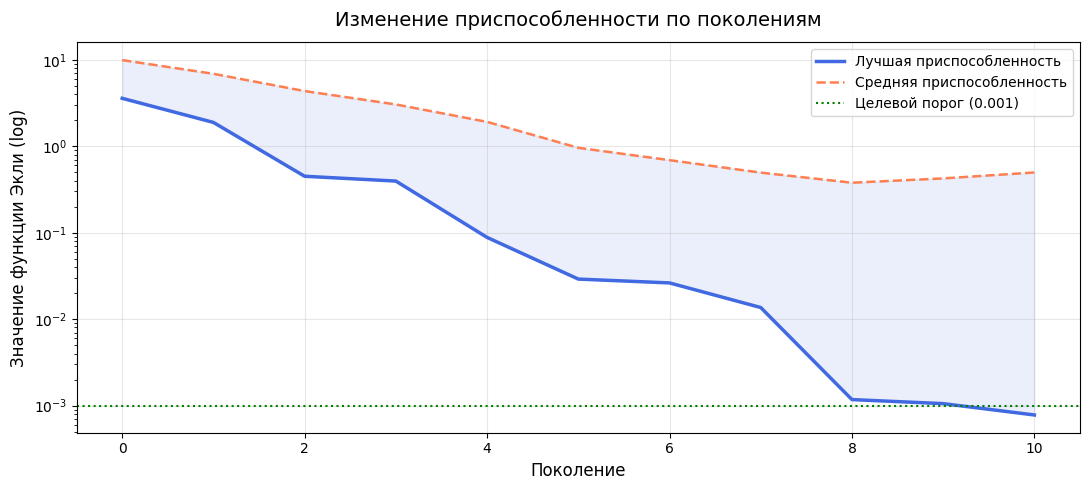

In [33]:
generations = list(range(len(history_best_fitness)))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(generations, history_best_fitness,
        color='royalblue', linewidth=2.5, label='Лучшая приспособленность')
ax.plot(generations, history_avg_fitness,
        color='coral', linewidth=1.8, linestyle='--', label='Средняя приспособленность')
ax.axhline(y=TARGET_FITNESS, color='green', linestyle=':',
           linewidth=1.5, label=f'Целевой порог ({TARGET_FITNESS})')
ax.fill_between(generations, history_best_fitness, history_avg_fitness,
                alpha=0.1, color='royalblue')

ax.set_title('Изменение приспособленности по поколениям', fontsize=14, pad=12)
ax.set_xlabel('Поколение', fontsize=12)
ax.set_ylabel('Значение функции Экли (log)', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Распределение особей в пространстве решений

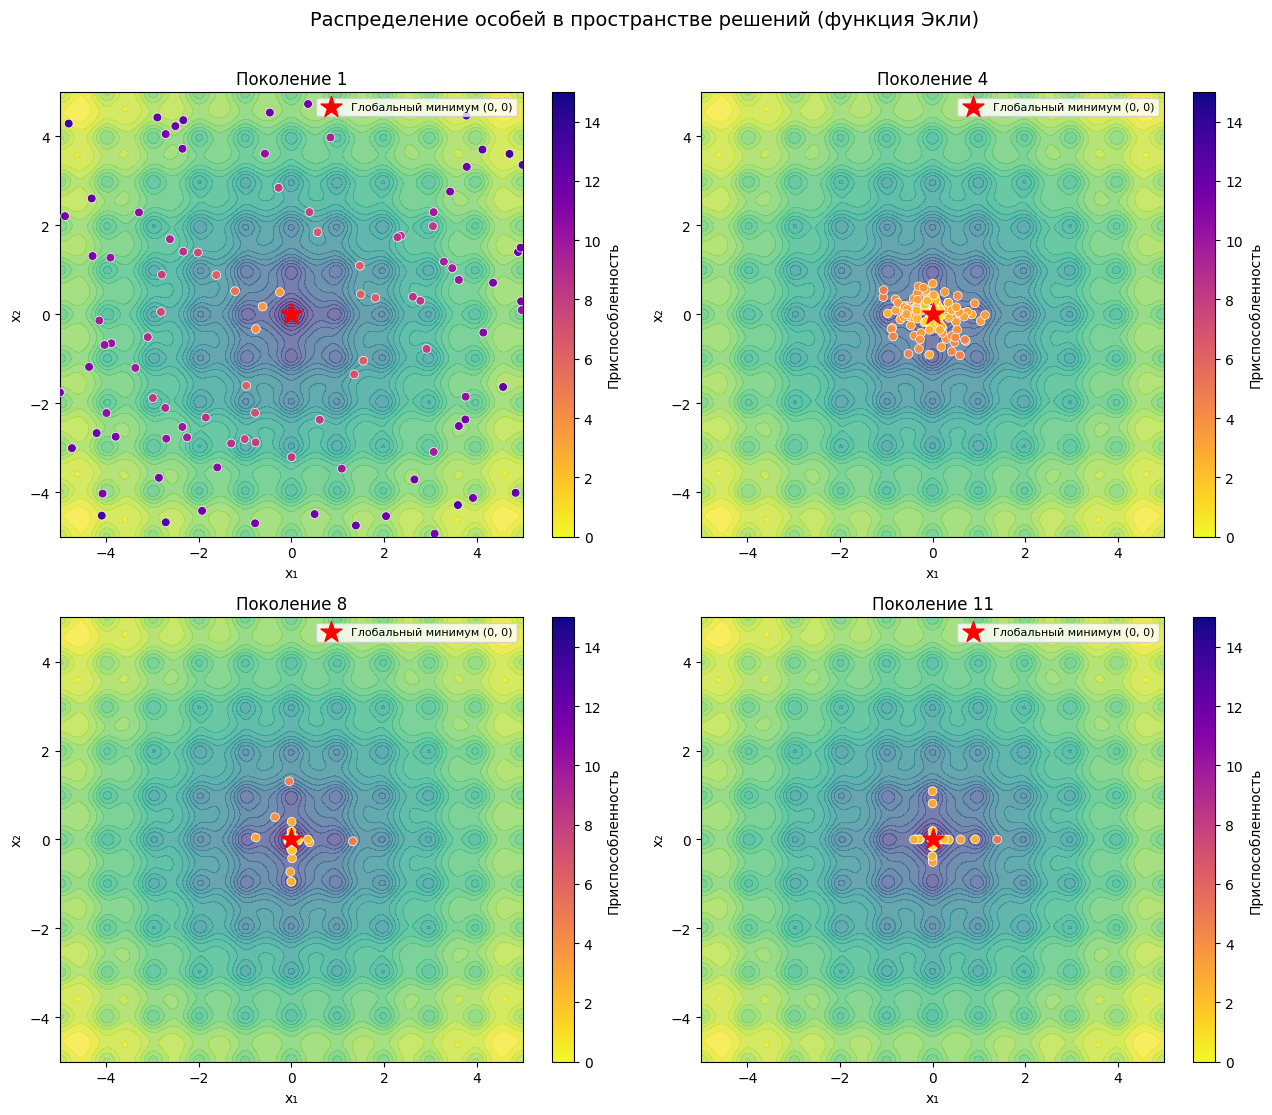

In [34]:
grid = np.linspace(BOUNDS[0], BOUNDS[1], 300)
X, Y = np.meshgrid(grid, grid)
Z = np.array([[ackley_function([X[i, j], Y[i, j]])
               for j in range(X.shape[1])]
              for i in range(X.shape[0])])

n = len(history_populations)
snap_gens = [0, n // 3, 2 * n // 3, n - 1]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, gen_idx in zip(axes, snap_gens):
    pop_snap = history_populations[gen_idx]
    xs = [p[0] for p in pop_snap]
    ys = [p[1] for p in pop_snap]
    fs = [p[2] for p in pop_snap]

    ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
    sc = ax.scatter(xs, ys, c=fs, cmap='plasma_r', s=40,
                    edgecolors='white', linewidths=0.5, zorder=3,
                    norm=Normalize(vmin=0, vmax=15))
    ax.scatter([0], [0], marker='*', s=250, color='red', zorder=5,
               label='Глобальный минимум (0, 0)')

    plt.colorbar(sc, ax=ax, label='Приспособленность')
    ax.set_title(f'Поколение {gen_idx + 1}', fontsize=12)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Распределение особей в пространстве решений (функция Экли)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7.3 График разнообразия популяции по поколениям

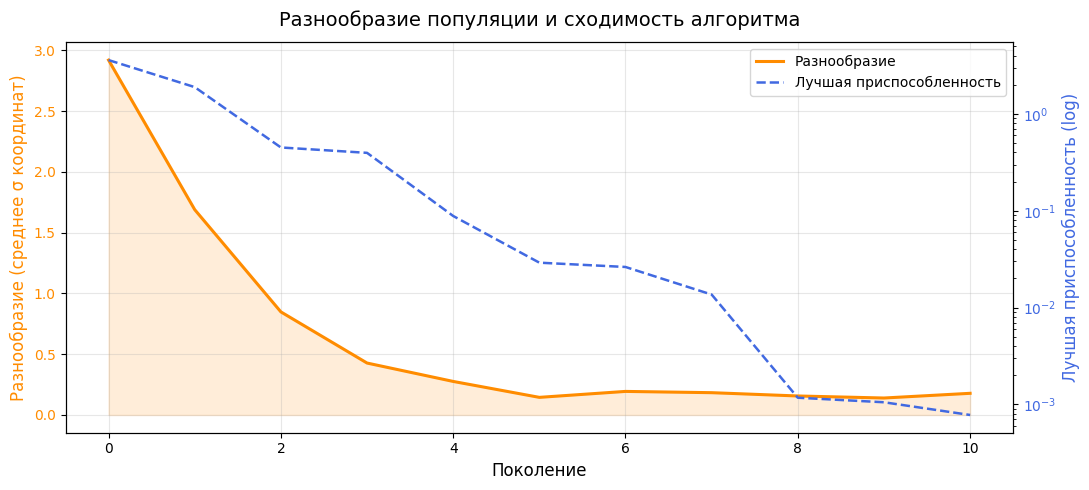

In [35]:
fig, ax1 = plt.subplots(figsize=(11, 5))

color_div  = 'darkorange'
color_best = 'royalblue'

ax1.set_xlabel('Поколение', fontsize=12)
ax1.set_ylabel('Разнообразие (среднее σ координат)', color=color_div, fontsize=12)
ax1.plot(generations, history_diversity,
         color=color_div, linewidth=2.2, label='Разнообразие')
ax1.fill_between(generations, 0, history_diversity,
                 alpha=0.15, color=color_div)
ax1.tick_params(axis='y', labelcolor=color_div)

ax2 = ax1.twinx()
ax2.set_ylabel('Лучшая приспособленность (log)', color=color_best, fontsize=12)
ax2.plot(generations, history_best_fitness,
         color=color_best, linewidth=1.8, linestyle='--',
         label='Лучшая приспособленность')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=color_best)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.set_title('Разнообразие популяции и сходимость алгоритма', fontsize=14, pad=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Анимация эволюции популяции

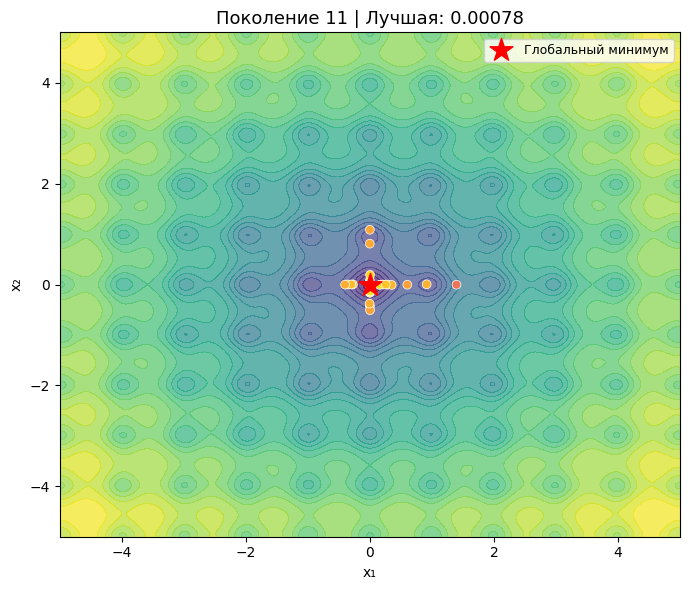

In [36]:
fig_a, ax_a = plt.subplots(figsize=(7, 6))
ax_a.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.7)
scat = ax_a.scatter([], [], c=[], cmap='plasma_r', s=40,
                    edgecolors='white', linewidths=0.5,
                    norm=Normalize(vmin=0, vmax=15))
ax_a.scatter([0], [0], marker='*', s=300, color='red',
             zorder=5, label='Глобальный минимум')
title_a = ax_a.set_title('', fontsize=13)
ax_a.set_xlabel('x₁')
ax_a.set_ylabel('x₂')
ax_a.legend(fontsize=9)

frames_idx = list(range(0, len(history_populations),
                        max(1, len(history_populations) // 50)))

def animate(frame_num):
    gen_idx  = frames_idx[frame_num]
    pop_snap = history_populations[gen_idx]
    xs = np.array([p[0] for p in pop_snap])
    ys = np.array([p[1] for p in pop_snap])
    fs = np.array([p[2] for p in pop_snap])
    scat.set_offsets(np.column_stack([xs, ys]))
    scat.set_array(fs)
    title_a.set_text(f'Поколение {gen_idx + 1} | '
                     f'Лучшая: {history_best_fitness[gen_idx]:.5f}')
    return scat, title_a

ani = FuncAnimation(fig_a, animate, frames=len(frames_idx),
                    interval=120, blit=True)
plt.tight_layout()
HTML(ani.to_jshtml())

## 8. Анализ результатов

In [37]:
print(f"Поколений выполнено  : {len(history_best_fitness)}")
print(f"Размер популяции     : {POP_SIZE}")
print(f"Вероятность мутации  : {MUTATION_RATE}")
print(f"Сила мутации         : {MUTATION_STRENGTH}")
print()
print(f"Найденные координаты : {[round(x, 6) for x in best_ever_chromosome]}")
print(f"Найденный минимум    : {best_ever_fitness:.8f}")
print(f"Отклонение           : {abs(best_ever_fitness):.2e}")

Поколений выполнено  : 11
Размер популяции     : 100
Вероятность мутации  : 0.1
Сила мутации         : 0.5

Найденные координаты : [0.000226, -0.000155]
Найденный минимум    : 0.00077782
Отклонение           : 7.78e-04


## 9. Многократный запуск

In [38]:
NUM_RUNS = 20

run_results = []

for run_idx in range(NUM_RUNS):
    seed = run_idx + 1
    random.seed(seed)
    np.random.seed(seed)

    population = create_initial_population(POP_SIZE, CHROM_LENGTH, BOUNDS)
    best_ever_fitness    = float('inf')
    best_ever_chromosome = None
    generations_done     = 0

    for generation in range(MAX_GENERATIONS):
        evaluate_population(population, ackley_function)
        best_ind, gen_best, gen_avg, gen_div = get_population_stats(population)
        generations_done = generation + 1

        if gen_best < best_ever_fitness:
            best_ever_fitness    = gen_best
            best_ever_chromosome = best_ind.chromosome.copy()

        if best_ever_fitness < TARGET_FITNESS:
            break

        new_population = []
        while len(new_population) < POP_SIZE:
            parent1 = selection(population)
            parent2 = selection(population)
            child1, child2 = crossover(parent1, parent2)
            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        for child in new_population:
            mutate(child, MUTATION_RATE, MUTATION_STRENGTH, BOUNDS)

        population = new_population

    run_results.append({
        'seed'    : seed,
        'fitness' : best_ever_fitness,
        'gens'    : generations_done,
        'coords'  : [round(x, 6) for x in best_ever_chromosome],
        'success' : best_ever_fitness < TARGET_FITNESS,
    })

all_fits = [r['fitness'] for r in run_results]
all_gens = [r['gens']    for r in run_results]
n_success = sum(r['success'] for r in run_results)

print(f"{'Запуск':>7} | {'Fitness':>12} | {'Поколений':>10} | {'Успех':>6} | Координаты")
print("-" * 72)
for r in run_results:
    mark = "  v" if r['success'] else "  x"
    print(f"{r['seed']:>7} | {r['fitness']:>12.8f} | {r['gens']:>10} | {mark:>6} | {r['coords']}")

print("-" * 72)
print(f"{'Среднее':>7} | {np.mean(all_fits):>12.8f} | {np.mean(all_gens):>10.1f} |")
print(f"{'Лучшее':>7} | {np.min(all_fits):>12.8f} | {int(np.min(all_gens)):>10}   |")
print(f"{'Худшее':>7} | {np.max(all_fits):>12.8f} | {int(np.max(all_gens)):>10}   |")
print(f"{'Ст. откл':>7} | {np.std(all_fits):>12.8f} |")
print(f"\nУспешных запусков: {n_success}/{NUM_RUNS} ({100*n_success/NUM_RUNS:.0f}%)")


 Запуск |      Fitness |  Поколений |  Успех | Координаты
------------------------------------------------------------------------
      1 |   0.00233144 |        100 |      x | [0.000606, 0.000549]
      2 |   0.00091535 |         10 |      v | [0.000312, 8.2e-05]
      3 |   0.00038891 |         17 |      v | [7.1e-05, -0.000118]
      4 |   0.00049597 |         12 |      v | [1e-06, -0.000175]
      5 |   0.00026941 |         12 |      v | [-3.7e-05, -8.8e-05]
      6 |   0.00073778 |         19 |      v | [-0.000242, -9.7e-05]
      7 |   0.00022471 |         10 |      v | [8e-06, 7.9e-05]
      8 |   0.00067331 |         12 |      v | [0.000123, -0.000203]
      9 |   0.00098067 |         14 |      v | [6.2e-05, 0.00034]
     10 |   0.00045292 |         11 |      v | [-6.3e-05, 0.000147]
     11 |   0.00053663 |         13 |      v | [0.000102, -0.00016]
     12 |   0.00048481 |         14 |      v | [-8.5e-05, -0.000149]
     13 |   0.00019165 |         14 |      v | [2.5e-05, -6

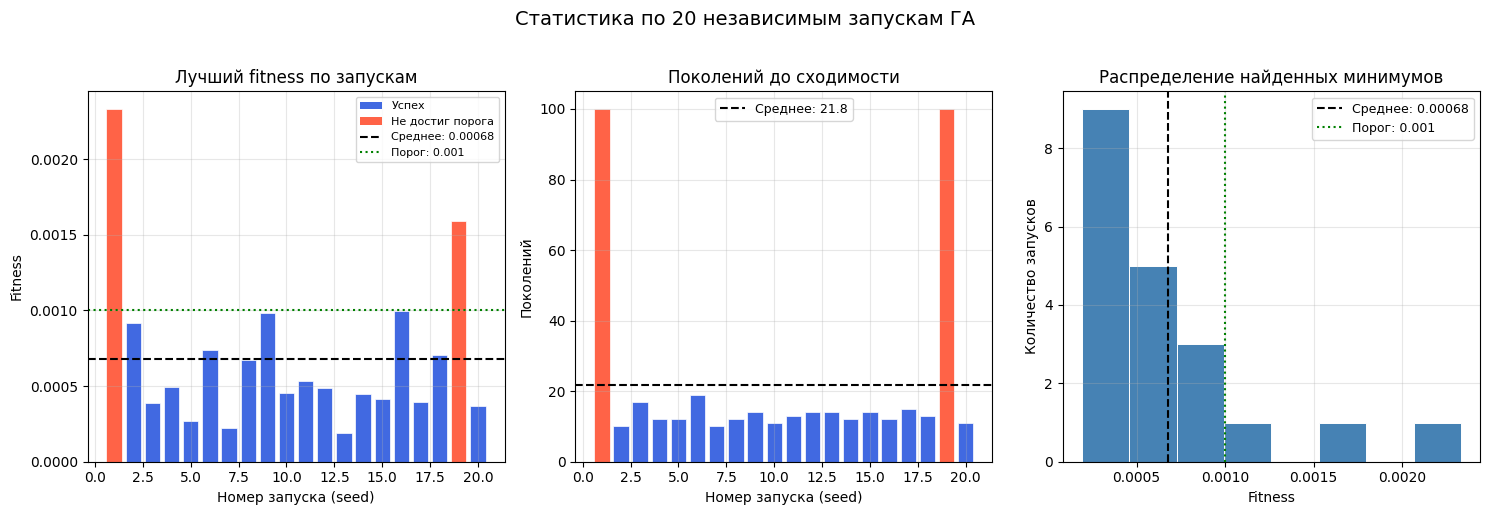

In [39]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['royalblue' if r['success'] else 'tomato' for r in run_results]
seeds  = [r['seed'] for r in run_results]

axes[0].bar(seeds, all_fits, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(np.mean(all_fits), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее: {np.mean(all_fits):.5f}')
axes[0].axhline(TARGET_FITNESS, color='green', linestyle=':', linewidth=1.5,
                label=f'Порог: {TARGET_FITNESS}')
legend_els = [Patch(facecolor='royalblue', label='Успех'),
              Patch(facecolor='tomato',     label='Не достиг порога'),
              plt.Line2D([0],[0], color='black', linestyle='--', label=f'Среднее: {np.mean(all_fits):.5f}'),
              plt.Line2D([0],[0], color='green',  linestyle=':',  label=f'Порог: {TARGET_FITNESS}')]
axes[0].legend(handles=legend_els, fontsize=8)
axes[0].set_title('Лучший fitness по запускам', fontsize=12)
axes[0].set_xlabel('Номер запуска (seed)')
axes[0].set_ylabel('Fitness')
axes[0].grid(True, alpha=0.3)

axes[1].bar(seeds, all_gens, color=colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(np.mean(all_gens), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее: {np.mean(all_gens):.1f}')
axes[1].set_title('Поколений до сходимости', fontsize=12)
axes[1].set_xlabel('Номер запуска (seed)')
axes[1].set_ylabel('Поколений')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].hist(all_fits, bins=8, color='steelblue', edgecolor='white', linewidth=0.7)
axes[2].axvline(np.mean(all_fits), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее: {np.mean(all_fits):.5f}')
axes[2].axvline(TARGET_FITNESS, color='green', linestyle=':', linewidth=1.5,
                label=f'Порог: {TARGET_FITNESS}')
axes[2].set_title('Распределение найденных минимумов', fontsize=12)
axes[2].set_xlabel('Fitness')
axes[2].set_ylabel('Количество запусков')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Статистика по {NUM_RUNS} независимым запускам ГА', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()